
# ML IDE Usage — Analysis Notebook (Mar–May 2025)

**Author:** _Filip Galiński_ 
**Goal:** End‑to‑end analytical thinking on a realistic dataset: exploration → patterns → visuals → insights.

---

## Table of Contents
1. [Context & Task](#context)
2. [Data Schema & Assumptions](#schema)
3. [Setup & Loading](#setup)
4. [Sanity Check (lite)](#sanity)
5. [Baseline Aggregations](#aggs)
6. [Requests ↔ Spent (correlation + scatter)](#corr)
7. [Weekly Trends (with MA3 & WoW)](#weekly)
8. [Combinations (model×feature, feature×license)](#combos)
9. [Feature Mix per Model (stacked & per‑model bars)](#mix)
10. [Efficiency — CPR (spent per request)](#cpr)
11. [Key Findings & Recommendations](#findings)
12. [Appendix: Repro & Notes](#appendix)

---

<a id="context"></a>
## 1) Context & Task
We analyse **daily aggregated usage** of ML features in an IDE across **Mar–May 2025**.  
Each row ≈ one user's day in a given `(license, model, feature)` tuple with two metrics:
- `requests_cnt` — number of requests issued that day for that tuple,
- `spent_amount` — corresponding spend for that activity.

Objective: understand patterns by model / feature / license, quantify the link between usage and spend, show trends, and propose actionable insights.

<a id="schema"></a>
## 2) Data Schema & Assumptions
Columns:
- **uuid** (string) — anonymized user id  
- **day_id** (date) — day of activity  
- **license** (string) — Basic / Standard / Enterprise / Premium  
- **model** (string) — Model_A … Model_E  
- **feature** (string) — Feature_1 … Feature_5  
- **requests_cnt** (float/int) — number of requests (non‑negative)  
- **spent_amount** (float) — spend for the same slice (non‑negative)

Assumptions: data is daily‑aggregated, ids are anonymized, metrics are consistent across rows.

<a id="setup"></a>
## 3) Setup & Loading
Below cells create output folders (`figures/`, `outputs/`), resolve `data/data.csv`, and load `df`.



<a id="sanity"></a>
## 4) Sanity Check (lite)
Quick structural overview: dtypes, basic stats, compact distributions, and metric quality checks.



<a id="aggs"></a>
## 5) Baseline Aggregations
Core rollups by **model**, **feature**, and **license** with totals & user counts.



<a id="corr"></a>
## 6) Requests ↔ Spent (correlation + scatter)
We compute Pearson/Spearman correlations and plot scatter to validate the relationship.



<a id="weekly"></a>
## 7) Weekly Trends (with MA3 & WoW)
Weekly sums, 3‑week moving average for smoothing, and week‑over‑week deltas.



<a id="combos"></a>
## 8) Combinations
- **model × feature**: where the volume comes from
- **feature × license**: which licenses carry each feature
Sorted matrices + compact Top‑10 for a crisp view.



<a id="mix"></a>
## 9) Feature Mix per Model
Two views:
- **100% stacked bar** across models with legend,
- **Per‑model bars** with % labels.



<a id="cpr"></a>
## 10) Efficiency — CPR (spent per request)
Compare monetization per request across dimensions; combine with volume for prioritization.


# 01 — Python Analysis (EDA, Trends, CPR)
**Zakres:** wczytanie danych, sanity-checki, agregacje Pandas, wykresy, eksporty.<br> 
Zaczynamy od wczytania danych i sprawdzenia czy wszystko się zgadza

In [40]:
# Importy
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd

KNOWN_REPO = Path(r"C:/Users/filip/PycharmProjects/pythonProject/ml-ide")
CANDIDATES += [
    KNOWN_REPO / "data" / "data.csv",
]

DATA = next((p for p in CANDIDATES if p.exists()), None)
if DATA is None:
    raise FileNotFoundError(
        "Nie znalazłem data.csv. Upewnij się, że plik jest w folderze repo: data/data.csv\n"
        f"Sprawdzone ścieżki:\n" + "\n".join(f" - {p}" for p in CANDIDATES)
    )

print("\n Używam pliku:", DATA.resolve())

df = pd.read_csv(DATA)
df['day_id'] = pd.to_datetime(df['day_id'])
df.head()



 Używam pliku: C:\Users\filip\PycharmProjects\pythonProject\ml-ide\data\data.csv


,uuid,day_id,license,model,feature,requests_cnt,spent_amount
0,user_920,2025-05-01,Premium,Model_A,Feature_1,44.0,16.38
1,user_717,2025-03-04,Premium,Model_B,Feature_2,72.0,27.92
2,user_610,2025-05-08,Premium,Model_A,Feature_2,27.0,9.87
3,user_94,2025-03-11,Basic,Model_D,Feature_1,76.0,14.67
4,user_920,2025-05-14,Premium,Model_E,Feature_3,47.0,9.88


In [52]:
def pretty_sanity_check(df, categorical=("license","model","feature"), date_col="day_id"):
    display(Markdown("## Quick sanity check"))

    # 1) Podstawowe info
    info_rows = [("rows", f"{len(df):,}"), ("columns", f"{df.shape[1]:,}")]
    if date_col in df.columns and np.issubdtype(df[date_col].dtype, np.datetime64):
        info_rows += [("date_min", str(df[date_col].min())), ("date_max", str(df[date_col].max()))]
    info_df = pd.DataFrame(info_rows, columns=["metric","value"])
    display(Markdown("### Podstawowe info"))
    display(info_df)

    # 2) Typy kolumn
    dtypes_df = pd.DataFrame({"column": df.columns, "dtype": df.dtypes.astype(str)}).reset_index(drop=True)
    display(Markdown("### Typy kolumn"))
    display(dtypes_df)

    # 3) Statystyki liczbowe (requests_cnt, spent_amount)
    num_cols = df.select_dtypes(include=[np.number]).columns
    if len(num_cols):
        num_summary = (
            df[num_cols]
            .agg(["count","mean","std","min","median","max"])
            .T.reset_index()
            .rename(columns={"index":"column"})
        )
        num_numeric_cols = num_summary.select_dtypes(include=[np.number]).columns
        fmt = {c: "{:,.3f}" for c in num_numeric_cols if c != "count"}
        fmt["count"] = "{:,.0f}"
        display(Markdown("### Statystyki liczbowe"))
        display(num_summary.style.format(fmt))

    # 4) Rozkłady kategorii)
    for col in categorical:
        if col in df.columns:
            vc = df[col].value_counts().rename("count").to_frame()
            vc["share_%"] = (vc["count"]/len(df)*100).round(2)
            display(Markdown(f"### Rozkład wartości — `{col}`"))
            display(vc.style.format({"share_%": "{:.2f}", "count": "{:,}"}))

    # 5) Jakość metryk
    checks = []
    for c in ["requests_cnt","spent_amount"]:
        if c in df.columns:
            checks.append((
                c,
                int((df[c] < 0).sum()),   # negatives
                df[c].min(),
                df[c].max(),
                df[c].isna().sum()        # nulls
            ))
    if checks:
        qchk = pd.DataFrame(checks, columns=["column","negatives","min","max","nulls"])
        display(Markdown("### Jakość metryk (negatives/min/max/nulls)"))
        display(qchk)

pretty_sanity_check(df)

## Quick sanity check

### Podstawowe info

,metric,value
0,rows,"122,746"
1,columns,7
2,date_min,2025-03-01 00:00:00
3,date_max,2025-05-31 00:00:00


### Typy kolumn

,column,dtype
0,uuid,object
1,day_id,datetime64[ns]
2,license,object
3,model,object
4,feature,object
5,requests_cnt,float64
6,spent_amount,float64


...

,count,share_%
model,,
Model_A,"38,042",30.99
Model_C,"24,433",19.91
Model_D,"24,423",19.90
Model_B,"23,110",18.83
Model_E,"12,738",10.38


### Rozkład wartości — `feature`

,count,share_%
feature,,
Feature_1,"45,399",36.99
Feature_2,"36,449",29.69
Feature_3,"26,283",21.41
Feature_5,"7,372",6.01
Feature_4,"7,243",5.90


### Jakość metryk (negatives/min/max/nulls)

,column,negatives,min,max,nulls
0,requests_cnt,0,1.00,12900.0,0
1,spent_amount,0,0.27,2599.0,0


## Agregacje bazowe

### Agregacja po modelu

,rank,model,requests_sum,spent_sum,users,requests_share_%,spent_share_%,CPR
2,1,Model_C,"1,941,796.0","366,622",644,30.86,24.43,0.1888
3,2,Model_D,"1,894,150.0","361,607",705,30.10,24.09,0.1909
0,3,Model_A,"991,933.0","365,077",843,15.76,24.32,0.3680
4,4,Model_E,"733,801.0","139,441",441,11.66,9.29,0.1900
1,5,Model_B,"730,371.0","268,166",610,11.61,17.87,0.3672


### Agregacja po feature

,rank,feature,requests_sum,spent_sum,users,requests_share_%,spent_share_%,CPR
0,1,Feature_1,"2,669,779.0","610,509","1,808",42.43,40.68,0.2287
1,2,Feature_2,"1,756,475.0","432,844","1,771",27.92,28.84,0.2464
2,3,Feature_3,"1,135,679.0","291,965","1,733",18.05,19.45,0.2571
3,4,Feature_4,"424,855.0","95,352","1,507",6.75,6.35,0.2244
4,5,Feature_5,"305,263.0","70,244","1,508",4.85,4.68,0.2301


### Agregacja po licencji

,rank,license,requests_sum,spent_sum,users,requests_share_%,spent_share_%,CPR
1,1,Enterprise,"1,925,374.0","473,238",251,30.60,31.53,0.2458
2,2,Premium,"1,719,628.0","403,972",247,27.33,26.92,0.2349
3,3,Standard,"1,568,926.0","367,450",708,24.94,24.48,0.2342
0,4,Basic,"1,078,123.0","256,254",717,17.13,17.07,0.2377


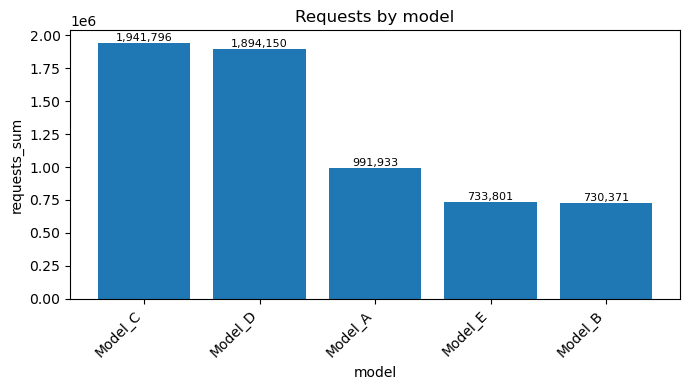

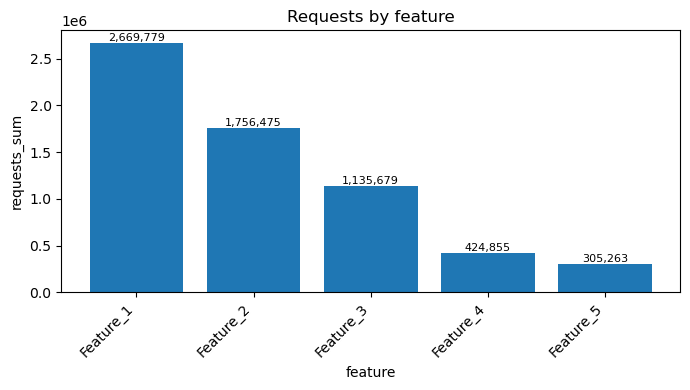

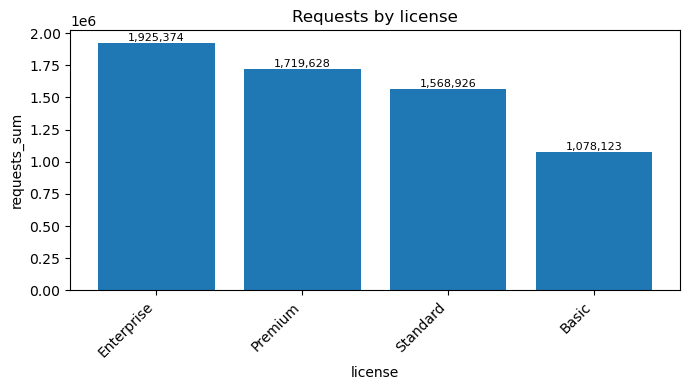

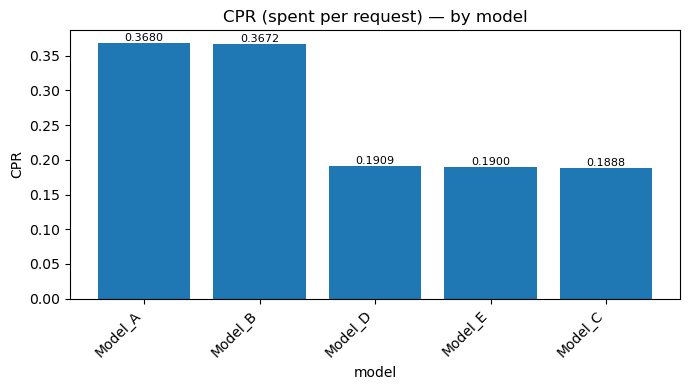

In [60]:
import pandas as pd

def agg_base(df, by):
    out = (df.groupby(by, as_index=False)
             .agg(requests_sum=('requests_cnt','sum'),
                  spent_sum=('spent_amount','sum'),
                  users=('uuid','nunique')))
    out = out.sort_values('requests_sum', ascending=False)
    # udziały
    out['requests_share_%'] = (out['requests_sum'] / out['requests_sum'].sum() * 100).round(2)
    out['spent_share_%']    = (out['spent_sum']    / out['spent_sum'].sum()    * 100).round(2)
    # KPI efektywności
    out['CPR'] = (out['spent_sum'] / out['requests_sum']).round(6)  # spent per request
    # ranking
    out.insert(0, 'rank', range(1, len(out)+1))
    return out

by_model   = agg_base(df, 'model')
by_feature = agg_base(df, 'feature')
by_license = agg_base(df, 'license')

# zapisz
by_model.to_csv(OUT/'by_model_pretty.csv', index=False)
by_feature.to_csv(OUT/'by_feature_pretty.csv', index=False)
by_license.to_csv(OUT/'by_license_pretty.csv', index=False)

# szybkie KPI do slajdu
kpi = {
    "Total requests": f"{int(df['requests_cnt'].sum()):,}",
    "Total spent":    f"{df['spent_amount'].sum():,.0f}",
    "Unique users":   f"{df['uuid'].nunique():,}",
}
kpi
from IPython.display import display, Markdown
import matplotlib.pyplot as plt
import numpy as np

def style_aggregation(frame, name):
    # tylko liczby do formatowania
    numeric_cols = frame.select_dtypes(include=[np.number]).columns
    fmt = {c: "{:,}" for c in ['requests_sum','users'] if c in frame.columns}
    if 'spent_sum' in frame.columns:
        fmt['spent_sum'] = "{:,.0f}"
    if 'requests_share_%' in frame.columns:
        fmt['requests_share_%'] = "{:.2f}"
    if 'spent_share_%' in frame.columns:
        fmt['spent_share_%'] = "{:.2f}"
    if 'CPR' in frame.columns:
        fmt['CPR'] = "{:,.4f}"

    display(Markdown(f"### {name}"))
    styled = (frame
              .style
              .format(fmt)
              .bar(subset=['requests_sum'], color='#d0e6ff', vmin=0)
              .bar(subset=['spent_sum'], color='#dff0d8', vmin=0))
    display(styled)

def bar_with_labels(frame, xcol, ycol, title, fname):
    xs = frame[xcol].astype(str).tolist()
    ys = frame[ycol].tolist()
    plt.figure(figsize=(7,4))
    bars = plt.bar(xs, ys)
    plt.title(title)
    plt.xlabel(xcol); plt.ylabel(ycol)
    plt.xticks(rotation=45, ha='right')
    # etykiety wartości
    for b, v in zip(bars, ys):
        plt.text(b.get_x() + b.get_width()/2, b.get_height(),
                 f"{int(v):,}" if isinstance(v,(int,np.integer)) or ycol.endswith('sum')
                 else f"{v:,.2f}",
                 ha='center', va='bottom', fontsize=8, rotation=0)
    plt.tight_layout()
    plt.savefig(FIG/fname, dpi=150)
    plt.show()

# — ładne tabele
style_aggregation(by_model,   "Agregacja po modelu")
style_aggregation(by_feature, "Agregacja po feature")
style_aggregation(by_license, "Agregacja po licencji")

# — trzy przejrzyste wykresy słupkowe (requests_sum)
bar_with_labels(by_model,   'model',   'requests_sum', 'Requests by model',   'bar_requests_by_model.png')
bar_with_labels(by_feature, 'feature', 'requests_sum', 'Requests by feature', 'bar_requests_by_feature.png')
bar_with_labels(by_license, 'license', 'requests_sum', 'Requests by license', 'bar_requests_by_license.png')

# — oraz wykres CPR (czytelna efektywność)
plt.figure(figsize=(7,4))
order = by_model.sort_values('CPR', ascending=False)
bars = plt.bar(order['model'].astype(str), order['CPR'])
plt.title('CPR (spent per request) — by model')
plt.xlabel('model'); plt.ylabel('CPR')
plt.xticks(rotation=45, ha='right')
for b, v in zip(bars, order['CPR']):
    plt.text(b.get_x() + b.get_width()/2, b.get_height(), f"{v:,.4f}", ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig(FIG/'bar_cpr_by_model.png', dpi=150)
plt.show()


## Związek requests ↔ spent (korelacja + scatter)

Interpretacja: blisko 1 = silna dodatnia zależność; blisko 0 = brak związku.
Korelacja requests_cnt ↔ spent_amount: 0.944


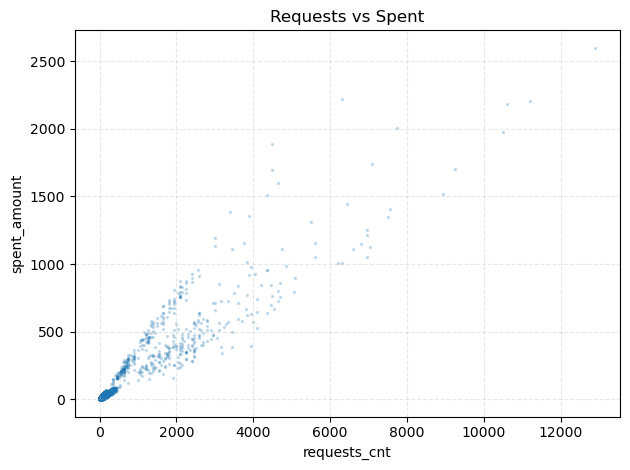

In [70]:

corr = df[['requests_cnt','spent_amount']].corr().loc['requests_cnt','spent_amount']
print("Interpretacja: blisko 1 = silna dodatnia zależność; blisko 0 = brak związku.")
print(f"Korelacja requests_cnt ↔ spent_amount: {corr:.3f}")

plt.figure()
plt.scatter(df['requests_cnt'], df['spent_amount'], s=2, alpha=0.2)
plt.title('Requests vs Spent')
plt.xlabel('requests_cnt')
plt.ylabel('spent_amount')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig(FIG/'scatter_requests_spent.png', dpi=150)
plt.show()


## Trendy tygodniowe

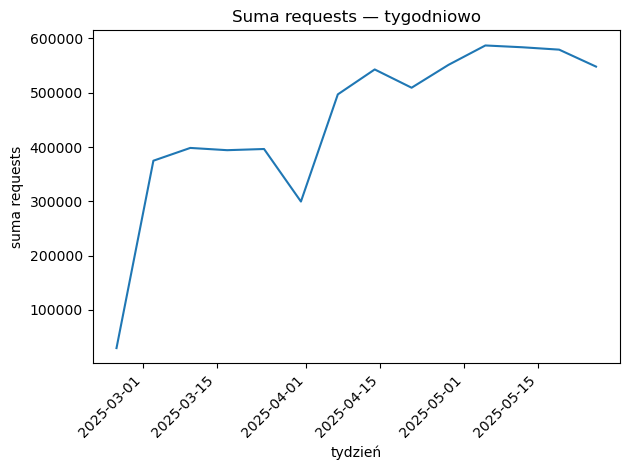

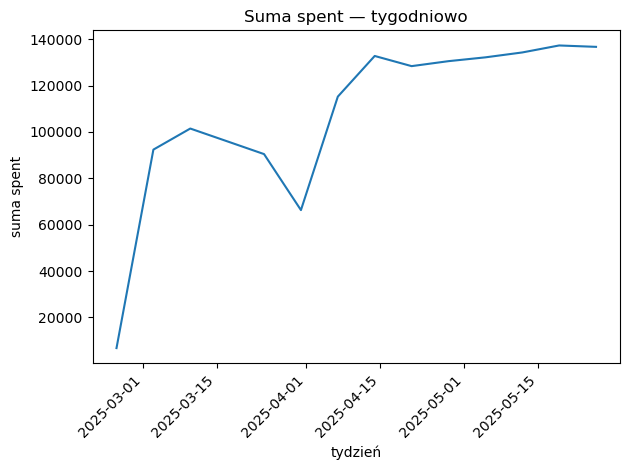

,week,requests_sum,spent_sum,users
0,2025-02-24,29627.0,6745.54,331
1,2025-03-03,374804.0,92386.44,1303
2,2025-03-10,398361.0,101481.88,1341
3,2025-03-17,394207.0,95973.88,1370
4,2025-03-24,396381.0,90452.57,1411


In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1) 
if not (np.issubdtype(df['day_id'].dtype, np.datetime64)):
    df['day_id'] = pd.to_datetime(df['day_id'], errors='coerce')

# 2) 
try:
    df['week'] = df['day_id'].dt.to_period('W').dt.start_time
except AttributeError:
    df['week'] = df['day_id'].dt.to_period('W').apply(lambda p: p.start_time)

# 3) Agregacja tygodniowa
trend_week = (df
    .groupby('week', as_index=False)
    .agg(requests_sum=('requests_cnt','sum'),
         spent_sum=('spent_amount','sum'),
         users=('uuid','nunique'))
    .sort_values('week'))

# 4) Zapis
try:
    trend_week.to_csv(OUT / 'trend_week.csv', index=False)
except Exception:
    pass

# 5) Wykresy
plt.figure()
plt.plot(trend_week['week'], trend_week['requests_sum'])
plt.title('Suma requests — tygodniowo')
plt.xlabel('tydzień'); plt.ylabel('suma requests')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
try:
    plt.savefig(FIG / 'trend_week_requests.png', dpi=150)
except Exception:
    pass
plt.show()

plt.figure()
plt.plot(trend_week['week'], trend_week['spent_sum'])
plt.title('Suma spent — tygodniowo')
plt.xlabel('tydzień'); plt.ylabel('suma spent')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
try:
    plt.savefig(FIG / 'trend_week_spent.png', dpi=150)
except Exception:
    pass
plt.show()

trend_week.head()



Odrazu widzimy silną zależność pomiędzy zapytaniami a ilością wydatków, co samo w sobie jest bardzo logiczne i ma sens

## Kombinacje (model, feature) i (feature, license)

In [105]:
import pandas as pd
import numpy as np

# 1) Pivot: requests per (model, feature)
mf_mat = df.pivot_table(index='model', columns='feature',
                        values='requests_cnt', aggfunc='sum').fillna(0)

# 2) totals i sort wiersze/kolumny po totalu malejąco
mf_mat['TOTAL'] = mf_mat.sum(axis=1)
col_total = mf_mat.sum(axis=0)
mf_mat = mf_mat.loc[mf_mat['TOTAL'].sort_values(ascending=False).index]
mf_mat = mf_mat[col_total.sort_values(ascending=False).index]

# 3) Udziały w wierszu (procent tego modelu rozbite na feature’y)
row_totals = mf_mat['TOTAL'].replace(0, np.nan)
mf_share = (mf_mat.div(row_totals, axis=0) * 100).round(1)
mf_share = mf_share.fillna(0.0)

# 4) druk (tysiące i %)
def fmt_th(x): 
    return f"{int(x):,}" if pd.notna(x) else ""
def fmt_pct(x):
    return f"{x:.1f}%" if pd.notna(x) else ""

print("### model × feature — WOLUMEN (requests)")
display(mf_mat.map(fmt_th))

print("\n### model × feature — UDZIAŁY w wierszu (≈ 100% na model)")
display(mf_share.map(fmt_pct))

# 5) csv
mf_mat.to_csv(OUT/'matrix_model_feature_requests.csv')
mf_share.to_csv(OUT/'matrix_model_feature_share_row.csv')


### model × feature — WOLUMEN (requests)


feature,TOTAL,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5
model,,,,,,
Model_C,"1,941,796","937,253","404,161","358,344","162,050","79,988"
Model_D,"1,894,150","798,043","603,601","251,417","124,580","116,509"
Model_A,"991,933","363,290","295,124","231,346","69,566","32,607"
Model_E,"733,801","329,741","200,811","110,376","52,162","40,711"
Model_B,"730,371","241,452","252,778","184,196","16,497","35,448"



### model × feature — UDZIAŁY w wierszu (≈ 100% na model)


feature,TOTAL,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5
model,,,,,,
Model_C,100.0%,48.3%,20.8%,18.5%,8.3%,4.1%
Model_D,100.0%,42.1%,31.9%,13.3%,6.6%,6.2%
Model_A,100.0%,36.6%,29.8%,23.3%,7.0%,3.3%
Model_E,100.0%,44.9%,27.4%,15.0%,7.1%,5.5%
Model_B,100.0%,33.1%,34.6%,25.2%,2.3%,4.9%


In [103]:
# 1) Pivot: requests per (feature, license)
fl_mat = df.pivot_table(index='feature', columns='license',
                        values='requests_cnt', aggfunc='sum').fillna(0)

# 2) Totals + sortowanie
fl_mat['TOTAL'] = fl_mat.sum(axis=1)
col_total = fl_mat.sum(axis=0)
fl_mat = fl_mat.loc[fl_mat['TOTAL'].sort_values(ascending=False).index]
fl_mat = fl_mat[col_total.sort_values(ascending=False).index]

# 3) Udziały w wierszu
row_totals = fl_mat['TOTAL'].replace(0, np.nan)
fl_share = (fl_mat.div(row_totals, axis=0) * 100).round(1).fillna(0.0)

print("### feature × license — WOLUMEN (requests)")
display(fl_mat.map(fmt_th))

print("\n### feature × license — UDZIAŁY w wierszu (≈ 100% na feature)")
display(fl_share.map(fmt_pct))

# 4) Eksport
fl_mat.to_csv(OUT/'matrix_feature_license_requests.csv')
fl_share.to_csv(OUT/'matrix_feature_license_share_row.csv')


### feature × license — WOLUMEN (requests)


license,TOTAL,Enterprise,Premium,Standard,Basic
feature,,,,,
Feature_1,"2,669,779","804,744","730,810","667,640","466,585"
Feature_2,"1,756,475","551,073","473,730","440,801","290,871"
Feature_3,"1,135,679","354,036","311,785","272,973","196,885"
Feature_4,"424,855","122,662","120,596","106,284","75,313"
Feature_5,"305,263","92,859","82,707","81,228","48,469"



### feature × license — UDZIAŁY w wierszu (≈ 100% na feature)


license,TOTAL,Enterprise,Premium,Standard,Basic
feature,,,,,
Feature_1,100.0%,30.1%,27.4%,25.0%,17.5%
Feature_2,100.0%,31.4%,27.0%,25.1%,16.6%
Feature_3,100.0%,31.2%,27.5%,24.0%,17.3%
Feature_4,100.0%,28.9%,28.4%,25.0%,17.7%
Feature_5,100.0%,30.4%,27.1%,26.6%,15.9%


In [101]:
top10 = (df.groupby(['model','feature'], as_index=False)
           .agg(requests_sum=('requests_cnt','sum'),
                spent_sum=('spent_amount','sum')))
top10['CPR'] = top10['spent_sum'] / top10['requests_sum']
top10 = top10.sort_values('requests_sum', ascending=False).head(10)

# czytelne formaty
t10_print = top10.copy()
t10_print['requests_sum'] = t10_print['requests_sum'].round(0).astype(int)
t10_print['spent_sum'] = t10_print['spent_sum'].round(0).astype(int)
t10_print['CPR'] = t10_print['CPR'].round(4)

display(t10_print)
top10.to_csv(OUT/'top10_model_feature_by_requests.csv', index=False)


,model,feature,requests_sum,spent_sum,CPR
10,Model_C,Feature_1,937253,174754,0.1865
15,Model_D,Feature_1,798043,152776,0.1914
16,Model_D,Feature_2,603601,114627,0.1899
11,Model_C,Feature_2,404161,76716,0.1898
0,Model_A,Feature_1,363290,132156,0.3638
12,Model_C,Feature_3,358344,68349,0.1907
20,Model_E,Feature_1,329741,62715,0.1902
1,Model_A,Feature_2,295124,108922,0.3691
6,Model_B,Feature_2,252778,94703,0.3747
17,Model_D,Feature_3,251417,48922,0.1946


## Pivot udziałów feature w ramach modelu

In [133]:
import pandas as pd
import numpy as np

# pivot: suma requests per (model, feature)
pivot = df.pivot_table(index='model', columns='feature', values='requests_cnt', aggfunc='sum').fillna(0)

# udziały % w obrębie modelu (wiersza) — 100% = suma po feature’ach dla danego modelu
share = pivot.div(pivot.sum(axis=1), axis=0).fillna(0)

# kolejność kolumn (feature’ów): globalnie wg sumy (bardziej „logiczny” porządek)
feature_order = pivot.sum(axis=0).sort_values(ascending=False).index.tolist()
share = share[feature_order]

# zapisz do CSV (ładne %)
share_csv = (share * 100).round(2)
share_csv.to_csv(OUT/'model_feature_share_row.csv')
share_csv.head()


feature,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5
model,,,,,
Model_A,36.62,29.75,23.32,7.01,3.29
Model_B,33.06,34.61,25.22,2.26,4.85
Model_C,48.27,20.81,18.45,8.35,4.12
Model_D,42.13,31.87,13.27,6.58,6.15
Model_E,44.94,27.37,15.04,7.11,5.55


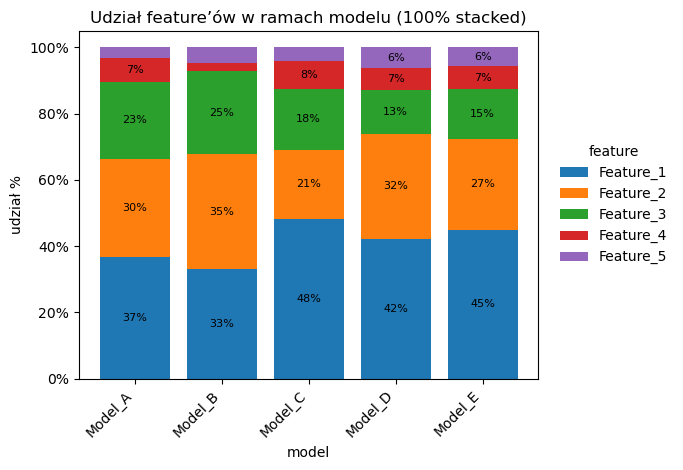

In [135]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as mtick

models = share.index.tolist()
features = share.columns.tolist()
vals = [share[c].values for c in features]

fig, ax = plt.subplots(figsize=(8.5, 4.8))
bottom = np.zeros(len(models))
bars = []
for feat_vals in vals:
    b = ax.bar(models, feat_vals, bottom=bottom)
    bars.append(b)
    bottom += feat_vals

ax.set_title('Udział feature’ów w ramach modelu (100% stacked)')
ax.set_xlabel('model')
ax.set_ylabel('udział %')

ax.xaxis.set_tick_params(labelrotation=45)       # zamiast: rotation=45, ha='right'
plt.setp(ax.get_xticklabels(), ha='right')       # wyrównanie etykiet osi X

ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# etykiety % dla segmentów ≥ 5%
for series, feat_vals in zip(bars, vals):
    for rect, v in zip(series, feat_vals):
        if v >= 0.05:
            ax.text(rect.get_x()+rect.get_width()/2,
                    rect.get_y()+rect.get_height()/2,
                    f"{v*100:.0f}%", ha='center', va='center', fontsize=8)

# LEGENDA PO PRAWEJ
handles = [b[0] for b in bars]
legend = ax.legend(handles, features, title="feature",
                   loc='center left', bbox_to_anchor=(1.02, 0.5),
                   frameon=False)

# zostawiamy miejsce na legendę po prawej
plt.tight_layout(rect=[0, 0, 0.82, 1])
plt.savefig(FIG/'stacked_100_model_feature_share.png', dpi=150,
            bbox_extra_artists=(legend,), bbox_inches='tight')
plt.show()


## Efektywność — spent per request (CPR)

In [93]:
def cpr(group_cols):
    res = (df.groupby(group_cols, as_index=False)
             .agg(requests_sum=('requests_cnt','sum'),
                  spent_sum=('spent_amount','sum'),
                  users=('uuid','nunique')))
    res['spent_per_request'] = res['spent_sum'] / res['requests_sum']
    return res.sort_values('spent_per_request', ascending=False)

eff_model = cpr(['model'])
eff_feature = cpr(['feature'])
eff_license = cpr(['license'])

eff_model.to_csv(OUT/'eff_model.csv', index=False)
eff_feature.to_csv(OUT/'eff_feature.csv', index=False)
eff_license.to_csv(OUT/'eff_license.csv', index=False)

eff_model.head(10)

,model,requests_sum,spent_sum,users,spent_per_request
0,Model_A,991933.0,365077.08,843,0.368046
1,Model_B,730371.0,268166.08,610,0.367164
3,Model_D,1894150.0,361607.23,705,0.190907
4,Model_E,733801.0,139441.21,441,0.190026
2,Model_C,1941796.0,366621.74,644,0.188805


In [138]:
from IPython.display import display, Markdown

def pretty_eff(frame, by_label):
    f = frame.copy()
    f = f.sort_values('spent_per_request', ascending=False).reset_index(drop=True)
    f.insert(0, 'rank', f.index+1)
    # formaty
    f['requests_sum_fmt'] = f['requests_sum'].map('{:,}'.format)
    f['spent_sum_fmt']    = f['spent_sum'].map('{:,.0f}'.format)
    f['CPR']              = f['spent_per_request'].map('{:,.4f}'.format)
    cols = ['rank', by_label, 'requests_sum_fmt', 'spent_sum_fmt', 'CPR', 'users']
    display(Markdown(f"### CPR — {by_label}"))
    display(f[cols])

pretty_eff(eff_model,   'model')
pretty_eff(eff_feature, 'feature')
pretty_eff(eff_license, 'license')

### CPR — model

,rank,model,requests_sum_fmt,spent_sum_fmt,CPR,users
0,1,Model_A,"991,933.0","365,077",0.3680,843
1,2,Model_B,"730,371.0","268,166",0.3672,610
2,3,Model_D,"1,894,150.0","361,607",0.1909,705
3,4,Model_E,"733,801.0","139,441",0.1900,441
4,5,Model_C,"1,941,796.0","366,622",0.1888,644


### CPR — feature

,rank,feature,requests_sum_fmt,spent_sum_fmt,CPR,users
0,1,Feature_3,"1,135,679.0","291,965",0.2571,1733
1,2,Feature_2,"1,756,475.0","432,844",0.2464,1771
2,3,Feature_5,"305,263.0","70,244",0.2301,1508
3,4,Feature_1,"2,669,779.0","610,509",0.2287,1808
4,5,Feature_4,"424,855.0","95,352",0.2244,1507


### CPR — license

,rank,license,requests_sum_fmt,spent_sum_fmt,CPR,users
0,1,Enterprise,"1,925,374.0","473,238",0.2458,251
1,2,Basic,"1,078,123.0","256,254",0.2377,717
2,3,Premium,"1,719,628.0","403,972",0.2349,247
3,4,Standard,"1,568,926.0","367,450",0.2342,708


In [142]:
min_requests = 50_000  # próg wolumenu, żeby odsiać mikroskopijne przypadki

mf_eff = (df.groupby(['model','feature'], as_index=False)
            .agg(requests_sum=('requests_cnt','sum'),
                 spent_sum=('spent_amount','sum')))
mf_eff['CPR'] = mf_eff['spent_sum'] / mf_eff['requests_sum']

mf_eff_filt = mf_eff[mf_eff['requests_sum'] >= min_requests].copy()
top_cpr = (mf_eff_filt.sort_values('CPR', ascending=False)
                      .head(10))

# czytelne formaty do podglądu
tmp = top_cpr.copy()
tmp['requests_sum'] = tmp['requests_sum'].map('{:,}'.format)
tmp['spent_sum']    = tmp['spent_sum'].map('{:,.0f}'.format)
tmp['CPR']          = tmp['CPR'].map('{:,.4f}'.format)
display(Markdown(f"### TOP 10 (model × feature) wg CPR — przy requests ≥ {min_requests:,}"))
display(tmp)

# eksport
top_cpr.to_csv(OUT/'top10_model_feature_by_cpr_filtered.csv', index=False)


### TOP 10 (model × feature) wg CPR — przy requests ≥ 50,000

,model,feature,requests_sum,spent_sum,CPR
2,Model_A,Feature_3,"231,346.0","86,721",0.3749
6,Model_B,Feature_2,"252,778.0","94,703",0.3747
1,Model_A,Feature_2,"295,124.0","108,922",0.3691
5,Model_B,Feature_1,"241,452.0","88,109",0.3649
0,Model_A,Feature_1,"363,290.0","132,156",0.3638
7,Model_B,Feature_3,"184,196.0","66,621",0.3617
3,Model_A,Feature_4,"69,566.0","25,076",0.3605
13,Model_C,Feature_4,"162,050.0","31,965",0.1973
17,Model_D,Feature_3,"251,417.0","48,922",0.1946
22,Model_E,Feature_3,"110,376.0","21,352",0.1934



<a id="findings"></a>
## 11) Key Findings & Recommendations (short)
- **Usage ↔ Spend:** strong positive correlation — higher usage translates to higher spend.
- **Concentration:** a few (model, feature) pairs drive most volume/spend → prioritise UX & latency there.
- **Feature mix:** Feature_1/Feature_2 dominate within most models; smaller features may need contextual onboarding.
- **CPR:** some models/features show materially higher CPR — candidates for premium packaging or usage‑based pricing tests.

**Next steps**
1. Focus on top (model×feature) combos: reliability & shortcuts in IDE.
2. Contextual prompts to increase adoption of long‑tail features.
3. Pricing/bundling experiments where CPR is consistently higher.
4. Monitor weekly trend to plan scaling/caching for common paths.



<a id="appendix"></a>
## 12) Appendix — Repro & Notes
- **How to run:** install `requirements.txt`, open this notebook, run cells top→bottom.
- **Outputs:** tables saved to `outputs/`, charts to `figures/`.
- **Reusability:** paths are relative; the notebook auto‑resolves `data/data.csv`.
- **Privacy:** user ids are anonymized; data contains aggregated signals only.
